# BBC Sport Project

## 1. Dataset

### 1-1 Dataset Investigation

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
import re
from sklearn.model_selection import train_test_split

In [2]:
# added for reproducibility

import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
### THIS PART OF THE CODE ONLY RUNS FOR ONCE TO CREATE "bbcsport_dataset.csv"


# base_path = "bbcsport-fulltext"   # folder created after extracting bbcsport-fulltext.zip

# data_rows = []

# # Walk through all class folders
# for root, dirs, files in os.walk(base_path):
#     for file in files:
#         if file.endswith(".txt"):
#             filepath = os.path.join(root, file)

#             # Label = name of the folder (athletics, cricket, football, rugby, tennis)
#             label = os.path.basename(root)

#             # Read the text content
#             with open(filepath, "r", encoding="latin1") as f:
#                 text = f.read().strip()

#             data_rows.append({
#                 "label": label,
#                 "filename": file,
#                 "text": text
#             })

# # Build DataFrame
# df = pd.DataFrame(data_rows)

# # Save to CSV
# df.to_csv("bbcsport_dataset.csv", index=False, encoding="utf-8")

# print("Number of documents:", len(df))
# print(df.sample(5))


In [ ]:
df = pd.read_csv("./data/processed/bbcsport_dataset.csv")
class_counts = df["label"].value_counts()


print("Total documents:", len(df))
print("Number of documents in each class:")
print(class_counts)

Total documents: 737
Number of documents in each class:
label
football     265
rugby        147
cricket      124
athletics    101
tennis       100
Name: count, dtype: int64


In [5]:
# Word count
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print("\nWord Count Statistics:")
print(df["word_count"].describe())


Word Count Statistics:
count     737.000000
mean      341.188602
std       187.969842
min       104.000000
25%       211.000000
50%       301.000000
75%       425.000000
max      1680.000000
Name: word_count, dtype: float64


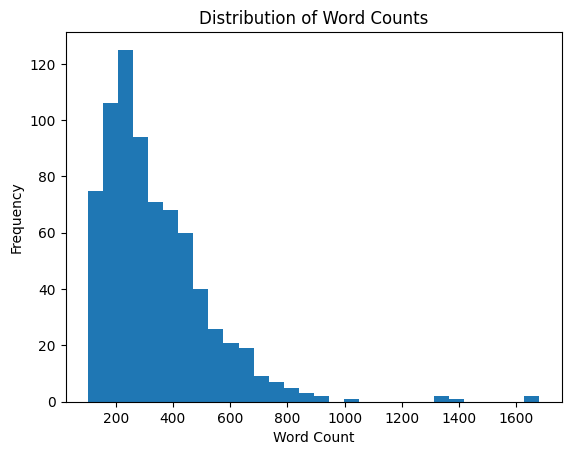

In [6]:
plt.hist(df["word_count"], bins=30)
plt.title("Distribution of Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

### 2-1 Preprocessing

In [7]:
df = pd.read_csv("bbcsport_dataset.csv")

texts = df['text'].astype(str).tolist()
labels = df['label'].astype(str).tolist()

In [8]:
import re
import numpy as np
import nltk
import time
import copy

nltk.download('stopwords')

from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# delete text noise + convert to lowercase

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))


def clean_text(x):
    x = re.sub(r'[^a-zA-Z0-9]', ' ', x)   # remove punctuation/special characters
    x = x.lower()                         # convert to lowercase
    words = x.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

corpus = [clean_text(x) for x in texts]

print("\nSample cleaned text:\n", corpus[3][:500])


Sample cleaned text:
 iaaf launch fight drug iaaf athlet world govern bodi met anti dope offici coach athlet co ordin fight drug sport two task forc set examin dope nutrit issu also agre programm de mystifi issu athlet public media prioriti noth decid chang thing forum stakehold allow express said iaaf spokesman get everyon togeth gave us lot food thought 60 peopl attend sunday meet monaco includ iaaf chief lamin diack namibian athlet franki frederick member athlet commiss happi see member athlet famili respond posit


In [10]:
# original text length
max_char_length = max(len(x) for x in texts)
print("\nMax original text length (characters):", max_char_length)

# Analyze cleaned token lengths
token_lengths = [len(x.split()) for x in corpus]
print("Min token length:", np.min(token_lengths))
print("Max token length:", np.max(token_lengths))
print("Mean token length:", np.mean(token_lengths))
print("Median token length:", np.median(token_lengths))


Max original text length (characters): 9645
Min token length: 64
Max token length: 1038
Mean token length: 197.56309362279512
Median token length: 167.0


In [11]:
#  Encode labels
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

print("\nClass mapping:")
for i, c in enumerate(label_encoder.classes_):
    print(f"{c} -> {i}")


Class mapping:
athletics -> 0
cricket -> 1
football -> 2
rugby -> 3
tennis -> 4


### 3-1 Dataset Preperation

In [12]:
from sklearn.model_selection import train_test_split

# First split: train_full and test
X_train_full, X_test, y_train_full, y_test_int = train_test_split(corpus,y_int,test_size=0.15,random_state=42,stratify=y_int)

# Second split: train and validation
X_train, X_val, y_train_int, y_val_int = train_test_split(X_train_full,y_train_full,test_size=0.1765,random_state=42,stratify=y_train_full)

# One-hot labels for Keras multiclass output
y_train = to_categorical(y_train_int, num_classes=num_classes)
y_val = to_categorical(y_val_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

print("\nSplit sizes:")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))


Split sizes:
Train: 515
Validation: 111
Test: 111


In [13]:
# Choose max sequence length using training data only
train_token_lengths = [len(x.split()) for x in X_train]

maxlen = int(np.percentile(train_token_lengths, 95))
print("Chosen maxlen from training set, 95th percentile:", maxlen)

Chosen maxlen from training set, 95th percentile: 391


In [14]:
# Tokenization

vocab_size = 10000

tokenizer = Tokenizer(
    num_words=vocab_size,
    lower=True,
    oov_token="<OOV>",
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~'
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [15]:
# Padding + Truncation

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

print("\nShapes:")
print("X_train:", X_train_pad.shape)
print("X_val:", X_val_pad.shape)
print("X_test:", X_test_pad.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)


Shapes:
X_train: (515, 391)
X_val: (111, 391)
X_test: (111, 391)
y_train: (515, 5)
y_val: (111, 5)
y_test: (111, 5)


## 2. Design and Model Training

### 2-1 LSTM Network

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import psutil
import time
import os

In [17]:
embedding_dim = 128

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen, mask_zero=True),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
# Train , Measure Time and RAM

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True)

process = psutil.Process(os.getpid())
lstm_ram_before_mb = process.memory_info().rss / (1024 ** 2)

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

lstm_training_time = time.time() - start_time

lstm_ram_after_mb = process.memory_info().rss / (1024 ** 2)
lstm_max_ram_mb = max(lstm_ram_before_mb, lstm_ram_after_mb)

print(f"\nTraining time: {lstm_training_time:.2f} seconds")
print(f"Approx. max RAM observed: {lstm_max_ram_mb:.2f} MB")

Epoch 1/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.3417 - loss: 1.5726 - val_accuracy: 0.3604 - val_loss: 1.4922
Epoch 2/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4408 - loss: 1.2814 - val_accuracy: 0.5225 - val_loss: 1.1068
Epoch 3/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8291 - loss: 0.5694 - val_accuracy: 0.9009 - val_loss: 0.4760
Epoch 4/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9728 - loss: 0.1986 - val_accuracy: 0.9279 - val_loss: 0.3155
Epoch 5/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9748 - loss: 0.1534 - val_accuracy: 0.9009 - val_loss: 0.3205
Epoch 6/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9825 - loss: 0.0887 - val_accuracy: 0.9459 - val_loss: 0.2344
Epoch 7/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9981 - loss: 0.0419 - val_accuracy: 0.9279 - val_loss: 0.3389
Epoch 8/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9942 - loss: 0.0373 - val_accuracy: 0.9369 - v

In [19]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 391, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 391, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,162,193 (15.88 MB)

 Trainable params: 1,387,397 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,774,796 (10.59 MB)

In [20]:
# Final Evaluation on test

lstm_train_loss, lstm_train_acc = lstm_model.evaluate(X_train_pad, y_train, verbose=0)
lstm_val_loss, lstm_val_acc = lstm_model.evaluate(X_val_pad, y_val, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)

print("\nFinal Results:")
print(f"Train Loss: {lstm_train_loss:.4f} | Train Accuracy: {lstm_train_acc:.4f}")
print(f"Val   Loss: {lstm_val_loss:.4f} | Val   Accuracy: {lstm_val_acc:.4f}")
print(f"Test  Loss: {lstm_test_loss:.4f} | Test  Accuracy: {lstm_test_acc:.4f}")


Final Results:
Train Loss: 0.0467 | Train Accuracy: 0.9922
Val   Loss: 0.1412 | Val   Accuracy: 0.9730
Test  Loss: 0.1401 | Test  Accuracy: 0.9550


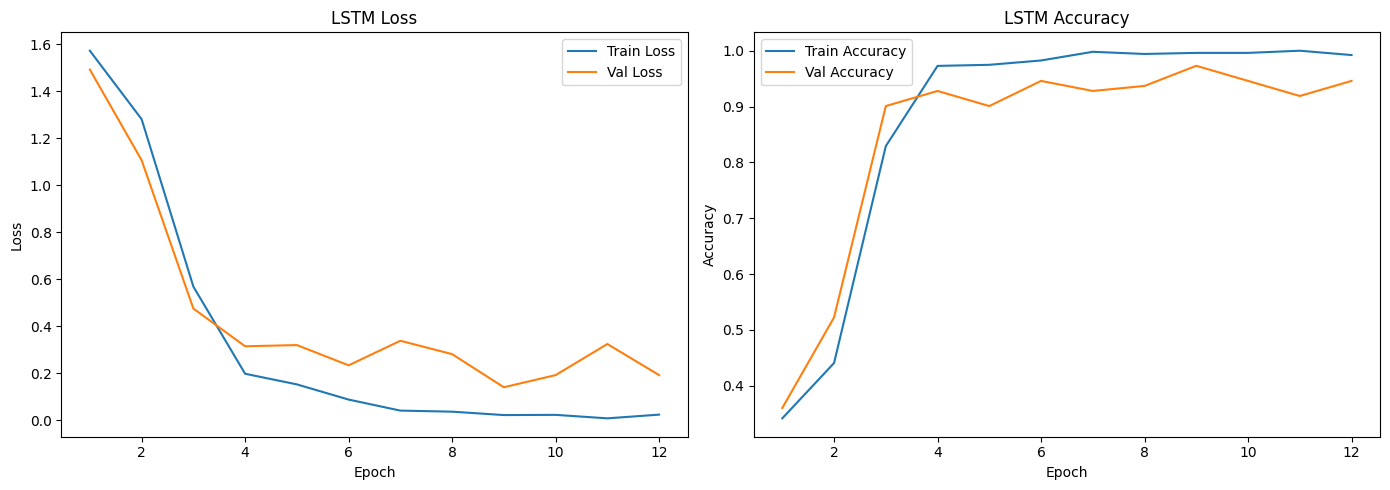

In [21]:
# Plots

epochs_ran = range(1, len(lstm_history.history['loss']) + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, lstm_history.history['loss'], label='Train Loss')
plt.plot(epochs_ran, lstm_history.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs_ran, lstm_history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 2-2 GRU Model

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, SpatialDropout1D
import tensorflow as tf
import time
import psutil
import os
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [23]:
# GRU Hyperparameters

embedding_dim = 128
gru_units = 128
num_gru_layers = 1
dropout_rate = 0.2
learning_rate = 0.001
batch_size = 32
epochs = 11
dense_units = 64
bidirectional = True

In [24]:
# GRU Model

def build_gru_model(vocab_size,
                    embedding_dim,
                    maxlen,
                    num_classes,
                    gru_units=128,
                    dropout_rate=0.2,
                    learning_rate=0.001,
                    dense_units=64
                    ):

    model = Sequential()

    gru_layer = GRU(units=gru_units,dropout=dropout_rate)

    model.add(Embedding(input_dim=vocab_size,output_dim=embedding_dim,input_length=maxlen,mask_zero=True))
    model.add(SpatialDropout1D(dropout_rate))
    model.add(Bidirectional(gru_layer))
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

    return model


gru_model = build_gru_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    maxlen=maxlen,
    num_classes=num_classes,
    gru_units=gru_units,
    dropout_rate=dropout_rate,
    learning_rate=learning_rate,
    dense_units=dense_units
)

In [25]:
# Training, training time and RAM

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

process = psutil.Process(os.getpid())
gru_ram_before_mb = process.memory_info().rss / (1024 ** 2)

start_time = time.time()

gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

gru_training_time = time.time() - start_time

gru_ram_after_mb = process.memory_info().rss / (1024 ** 2)
gru_max_ram_mb = max(gru_ram_before_mb, gru_ram_after_mb)

print(f"\nGRU training time: {gru_training_time:.2f} seconds")
print(f"Approx. max RAM observed: {gru_max_ram_mb:.2f} MB")

Epoch 1/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.3126 - loss: 1.5799 - val_accuracy: 0.3604 - val_loss: 1.5278
Epoch 2/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3592 - loss: 1.4667 - val_accuracy: 0.3604 - val_loss: 1.4147
Epoch 3/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5126 - loss: 1.1416 - val_accuracy: 0.5946 - val_loss: 1.2156
Epoch 4/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8291 - loss: 0.7334 - val_accuracy: 0.7658 - val_loss: 0.7243
Epoch 5/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9709 - loss: 0.1893 - val_accuracy: 0.9009 - val_loss: 0.3335
Epoch 6/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9981 - loss: 0.0286 - val_accuracy: 0.9550 - val_loss: 0.1911
Epoch 7/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9961 - loss: 0.0143 - val_accuracy: 0.9279 - val_loss: 0.2099
Epoch 8/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9981 - loss: 0.0088 - val_accuracy: 0.9099 - v

In [26]:
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 391, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 391, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,484,753 (17.11 MB)

 Trainable params: 1,494,917 (5.70 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,989,836 (11.41 MB)

In [27]:
# Final Evaluation on test

gru_train_loss, gru_train_acc = gru_model.evaluate(X_train_pad, y_train, verbose=0)
gru_val_loss, gru_val_acc = gru_model.evaluate(X_val_pad, y_val, verbose=0)
gru_test_loss, gru_test_acc = gru_model.evaluate(X_test_pad, y_test, verbose=0)

print("\nFinal Results:")
print(f"Train Loss: {gru_train_loss:.4f} | Train Accuracy: {gru_train_acc:.4f}")
print(f"Val   Loss: {gru_val_loss:.4f} | Val   Accuracy: {gru_val_acc:.4f}")
print(f"Test  Loss: {gru_test_loss:.4f} | Test  Accuracy: {gru_test_acc:.4f}")


Final Results:
Train Loss: 0.0003 | Train Accuracy: 1.0000
Val   Loss: 0.1375 | Val   Accuracy: 0.9640
Test  Loss: 0.1257 | Test  Accuracy: 0.9550


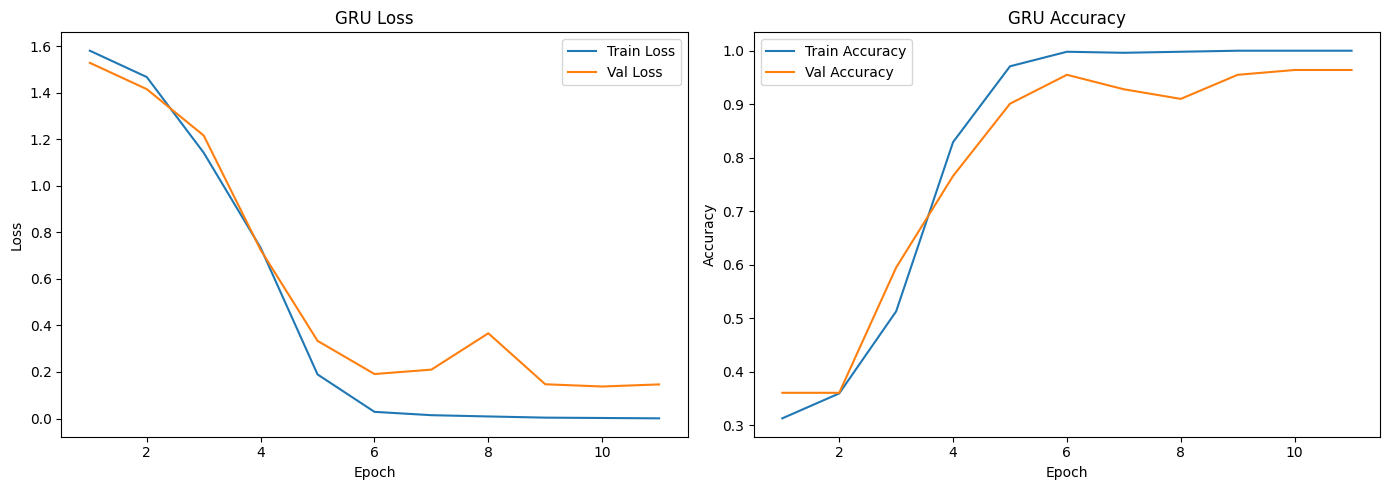

In [28]:
# Plots

epochs_ran = range(1, len(gru_history.history['loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, gru_history.history['loss'], label='Train Loss')
plt.plot(epochs_ran, gru_history.history['val_loss'], label='Val Loss')
plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, gru_history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs_ran, gru_history.history['val_accuracy'], label='Val Accuracy')
plt.title('GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Evaluation and Comparison

### 3-1 LSTM and GRU Comparison

In [29]:
comparison_df = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "Train Accuracy": [lstm_train_acc, gru_train_acc],
    "Validation Accuracy": [lstm_val_acc, gru_val_acc],
    "Test Accuracy": [lstm_test_acc, gru_test_acc],
    "Train Loss": [lstm_train_loss, gru_train_loss],
    "Validation Loss": [lstm_val_loss, gru_val_loss],
    "Test Loss": [lstm_test_loss, gru_test_loss],
    "Training Time Seconds": [lstm_training_time, gru_training_time],
    "Maximum Training RAM": [lstm_max_ram_mb, gru_max_ram_mb],
})

print(comparison_df)

  Model  Train Accuracy  Validation Accuracy  Test Accuracy  Train Loss  \
0  LSTM        0.992233             0.972973       0.954955    0.046740   
1   GRU        1.000000             0.963964       0.954955    0.000282   

   Validation Loss  Test Loss  Training Time Seconds  Maximum Training RAM  
0         0.141155   0.140070              17.252451           1480.792969  
1         0.137476   0.125699              12.559709           1528.410156  


### 3-2 input Text Length

In [30]:
import seaborn as sns

In [31]:
# 3 input lengths : Short / Medium / Long

train_lengths = np.array([len(x.split()) for x in X_train])

short_len = int(np.percentile(train_lengths, 50))    # median of training set
medium_len = int(np.percentile(train_lengths, 95))   # 95th percentile of training set
long_len = int(np.percentile(train_lengths, 99))     # 99th percentile of training set

maxlen_options = {
    "Short": short_len,
    "Medium": medium_len,
    "Long": long_len
}

print("Chosen maxlen values (from training set only):")
for name, value in maxlen_options.items():
    print(f"{name}: {value}")

Chosen maxlen values (from training set only):
Short: 170
Medium: 391
Long: 551


In [32]:
# tokenizer and labels

vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

train_seq_lengths = np.array([len(seq) for seq in X_train_seq])

results = []

In [33]:
# Train and compare models

for length_name, maxlen in maxlen_options.items():

    print("\n" + "=" * 60)
    print(f"Training GRU with {length_name} length: maxlen={maxlen}")
    print("=" * 60)

    # Pad according to current maxlen
    X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding="post", truncating="post")
    X_val_pad = pad_sequences(X_val_seq, maxlen=maxlen, padding="post", truncating="post")
    X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding="post", truncating="post")

    # Build model
    gru_model = build_gru_model(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        maxlen=maxlen,
        num_classes=num_classes,
        gru_units=gru_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        dense_units=dense_units,
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    # Measure RAM and time
    process = psutil.Process(os.getpid())
    ram_before = process.memory_info().rss / (1024 ** 2)

    start_time = time.time()

    gru_history = gru_model.fit(
        X_train_pad,
        y_train,
        validation_data=(X_val_pad, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    training_time = time.time() - start_time
    ram_after = process.memory_info().rss / (1024 ** 2)

    # Evaluate
    train_loss, train_acc = gru_model.evaluate(X_train_pad, y_train, verbose=0)
    val_loss, val_acc = gru_model.evaluate(X_val_pad, y_val, verbose=0)
    test_loss, test_acc = gru_model.evaluate(X_test_pad, y_test, verbose=0)

    results.append({
        "Length Type": length_name,
        "Maxlen": maxlen,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Test Accuracy": test_acc,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Test Loss": test_loss,
        "Epochs Ran": len(gru_history.history["loss"]),
        "Training Time Sec": training_time,
        "RAM Change MB": ram_after - ram_before,
        "Total Params": gru_model.count_params(),
    })


Training GRU with Short length: maxlen=170
Epoch 1/11


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3301 - loss: 1.5829 - val_accuracy: 0.3604 - val_loss: 1.5404
Epoch 2/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3592 - loss: 1.4675 - val_accuracy: 0.3604 - val_loss: 1.4239
Epoch 3/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5223 - loss: 1.1842 - val_accuracy: 0.6216 - val_loss: 0.9159
Epoch 4/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8544 - loss: 0.7186 - val_accuracy: 0.7297 - val_loss: 0.7719
Epoch 5/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9553 - loss: 0.2958 - val_accuracy: 0.7658 - val_loss: 0.6342
Epoch 6/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9961 - loss: 0.0964 - val_accuracy: 0.8018 - val_loss: 0.5103
Epoch 7/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9942 - loss: 0.0353 - val_accuracy: 0.8468 - val_loss: 0.4665
Epoch 8/11
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 0.8378 - val_loss: 0.

In [34]:
# "Results" table

results_df = pd.DataFrame(results)

print("\nFinal comparison:")
display(results_df)

results_df.to_csv("gru_input_length_comparison.csv", index=False)


Final comparison:


,Length Type,Maxlen,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss,Epochs Ran,Training Time Sec,RAM Change MB,Total Params
0,Short,170,1.0,0.828829,0.873874,0.000532,0.409167,0.410561,11,13.207750,52.015625,1494917
1,Medium,391,1.0,0.945946,0.954955,0.000191,0.141913,0.182489,11,12.753042,60.355469,1494917
2,Long,551,1.0,0.909910,0.873874,0.052253,0.269331,0.323608,9,10.849792,-12.136719,1494917


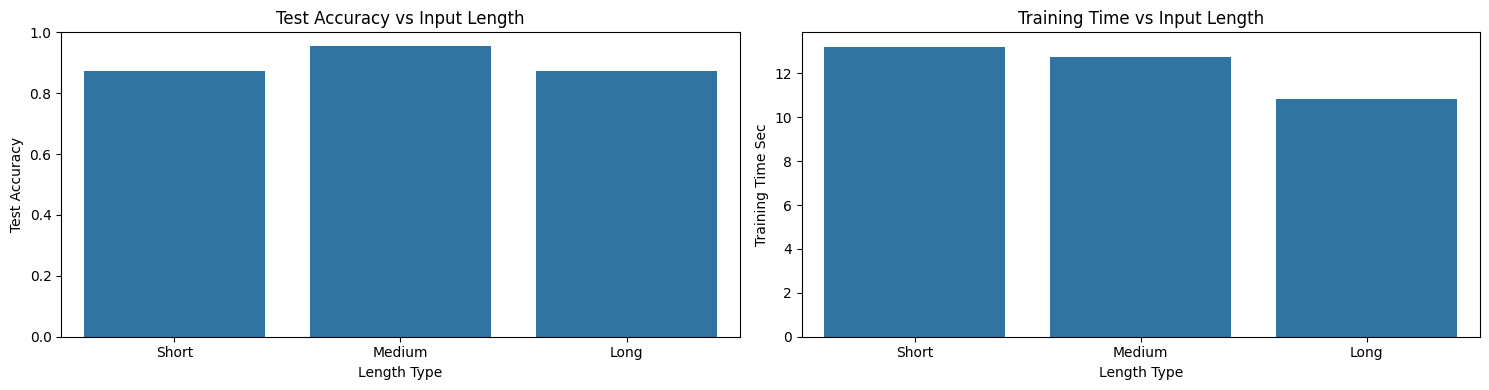

In [35]:
# Plot GRU input length comparison

plt.figure(figsize=(15,4))

plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x="Length Type", y="Test Accuracy")
plt.title("Test Accuracy vs Input Length")
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x="Length Type", y="Training Time Sec")
plt.title("Training Time vs Input Length")

plt.tight_layout()
plt.show()